In [57]:
!pip install yfinance pandas pyarrow pandas-gbq \
             google-cloud-storage

In [58]:
import os

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/content/ai-market-risk-engine.json"


In [59]:
from google.cloud import storage, bigquery

# Test GCS
storage_client = storage.Client()
[b.name for b in storage_client.list_buckets()]

# Test BigQuery
bq = bigquery.Client()
[d.dataset_id for d in bq.list_datasets()]


['market_risk']

In [60]:
from google.cloud import bigquery
import os

# Ensure service account is set (adjust filename if needed)
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/content/ai-market-risk-engine.json"

PROJECT_ID = "ai-market-risk-engine"
DATASET_ID = "market_risk"
LOCATION = "US"   # IMPORTANT: must match future loads

bq = bigquery.Client(project=PROJECT_ID)

dataset_ref = f"{PROJECT_ID}.{DATASET_ID}"
dataset = bigquery.Dataset(dataset_ref)
dataset.location = LOCATION

# Create dataset if it doesn't exist
dataset = bq.create_dataset(dataset, exists_ok=True)

print(f"✅ Dataset ready: {dataset_ref} (location={dataset.location})")


✅ Dataset ready: ai-market-risk-engine.market_risk (location=us-central1)


In [61]:
import yfinance as yf
import pandas as pd
import numpy as np

TICKERS = ["AAPL", "MSFT", "AMZN", "NVDA", "GOOGL"]
START_DATE = "2019-01-01"

In [62]:
test_df = yf.download(
    "AAPL",
    start=START_DATE,
    auto_adjust=False,
    progress=False
)

type(test_df.columns), test_df.head()


(pandas.core.indexes.multi.MultiIndex,
 Price       Adj Close      Close       High        Low       Open     Volume
 Ticker           AAPL       AAPL       AAPL       AAPL       AAPL       AAPL
 Date                                                                        
 2019-01-02  37.538815  39.480000  39.712502  38.557499  38.722500  148158800
 2019-01-03  33.799679  35.547501  36.430000  35.500000  35.994999  365248800
 2019-01-04  35.242561  37.064999  37.137501  35.950001  36.132500  234428400
 2019-01-07  35.164112  36.982498  37.207500  36.474998  37.174999  219111200
 2019-01-08  35.834454  37.687500  37.955002  37.130001  37.389999  164101200)

In [63]:
def normalize_yf_columns(df: pd.DataFrame) -> pd.DataFrame:
    # Reset index first
    df = df.reset_index()

    # Flatten MultiIndex if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [c[0] for c in df.columns]
    else:
        df.columns = list(df.columns)

    # Normalize names
    df.columns = [c.lower().replace(" ", "_") for c in df.columns]

    return df


In [64]:
all_data = []

for t in TICKERS:
    df = yf.download(
        t,
        start=START_DATE,
        auto_adjust=False,
        progress=False
    )

    df = normalize_yf_columns(df)
    df["ticker"] = t

    # Explicit canonical schema (prevents duplicates)
    df = df[
        ["date", "open", "high", "low", "close", "adj_close", "volume", "ticker"]
    ]

    all_data.append(df)

prices_df = pd.concat(all_data, ignore_index=True)
prices_df.head()


,date,open,high,low,close,adj_close,volume,ticker
0,2019-01-02,38.722500,39.712502,38.557499,39.480000,37.538822,148158800,AAPL
1,2019-01-03,35.994999,36.430000,35.500000,35.547501,33.799671,365248800,AAPL
2,2019-01-04,36.132500,37.137501,35.950001,37.064999,35.242558,234428400,AAPL
3,2019-01-07,37.174999,37.207500,36.474998,36.982498,35.164108,219111200,AAPL
4,2019-01-08,37.389999,37.955002,37.130001,37.687500,35.834446,164101200,AAPL


In [65]:
prices_df["date"] = pd.to_datetime(prices_df["date"])
prices_df = prices_df.sort_values(["ticker", "date"])

prices_df.dtypes


,0
date,datetime64[ns]
open,float64
high,float64
low,float64
close,float64
adj_close,float64
volume,int64
ticker,object


In [66]:
local_path = "/content/prices_raw.parquet"
prices_df.to_parquet(local_path, index=False)
print("✅ Parquet saved locally:", local_path)


✅ Parquet saved locally: /content/prices_raw.parquet


In [67]:
from google.cloud import storage
import os

PROJECT_ID = "ai-market-risk-engine"      # change if different
BUCKET_NAME = "market-risk-omkar"          # change if different

storage_client = storage.Client(project=PROJECT_ID)
bucket = storage_client.bucket(BUCKET_NAME)


In [68]:
blob = bucket.blob("raw/prices/prices_raw.parquet")
blob.upload_from_filename(local_path)

print("✅ Uploaded to GCS: raw/prices/prices_raw.parquet")


✅ Uploaded to GCS: raw/prices/prices_raw.parquet


In [69]:
[b.name for b in bucket.list_blobs(prefix="raw/prices/")]


['raw/prices/prices_raw.parquet']

In [70]:
from google.cloud import bigquery
import os

PROJECT_ID = "ai-market-risk-engine"

bq = bigquery.Client(project=PROJECT_ID)

print("Connected project:", bq.project)
print("Service account:", bq._credentials.service_account_email)


Connected project: ai-market-risk-engine
Service account: market-risk-sa@ai-market-risk-engine.iam.gserviceaccount.com


In [71]:
datasets = list(bq.list_datasets())
[d.dataset_id for d in datasets]


['market_risk']

In [72]:
from google.cloud import bigquery

PROJECT_ID = "ai-market-risk-engine"
DATASET_ID = "market_risk"
TABLE_ID = "prices_daily"

bq = bigquery.Client(project=PROJECT_ID)

dataset_ref = bq.dataset(DATASET_ID)
print("Dataset reference:", dataset_ref)


Dataset reference: ai-market-risk-engine.market_risk


In [73]:
table_ref = dataset_ref.table(TABLE_ID)
print("Table reference:", table_ref)


Table reference: ai-market-risk-engine.market_risk.prices_daily


In [74]:
GCS_URI = "gs://market-risk-omkar/raw/prices/prices_raw.parquet"

job_config = bigquery.LoadJobConfig(
    source_format=bigquery.SourceFormat.PARQUET,
    autodetect=True,
    write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE
)

load_job = bq.load_table_from_uri(
    GCS_URI,
    table_ref,
    job_config=job_config
)

load_job.result()  # wait for completion

print("✅ BigQuery load job completed successfully")


✅ BigQuery load job completed successfully


In [75]:
tables = list(bq.list_tables(DATASET_ID))
[t.table_id for t in tables]


['features_market', 'model_dataset', 'prices_clean', 'prices_daily']

In [76]:
bq.query("""
SELECT
  ticker,
  COUNT(*) AS row_count
FROM `ai-market-risk-engine.market_risk.prices_daily`
GROUP BY ticker
""").to_dataframe(bqstorage_client=False)


,ticker,row_count
0,AAPL,1777
1,AMZN,1777
2,GOOGL,1777
3,MSFT,1777
4,NVDA,1777


In [77]:
from google.cloud import bigquery
import pandas as pd
import numpy as np

PROJECT_ID = "ai-market-risk-engine"
DATASET_ID = "market_risk"
SOURCE_TABLE = "prices_daily"

bq = bigquery.Client(project=PROJECT_ID)

query = f"""
SELECT *
FROM `{PROJECT_ID}.{DATASET_ID}.{SOURCE_TABLE}`
ORDER BY ticker, date
"""

prices = bq.query(query).to_dataframe(bqstorage_client=False)
prices.head()


,date,open,high,low,close,adj_close,volume,ticker
0,1546387200000000000,38.722500,39.712502,38.557499,39.480000,37.538822,148158800,AAPL
1,1546473600000000000,35.994999,36.430000,35.500000,35.547501,33.799671,365248800,AAPL
2,1546560000000000000,36.132500,37.137501,35.950001,37.064999,35.242558,234428400,AAPL
3,1546819200000000000,37.174999,37.207500,36.474998,36.982498,35.164108,219111200,AAPL
4,1546905600000000000,37.389999,37.955002,37.130001,37.687500,35.834446,164101200,AAPL


In [78]:
prices["date"] = pd.to_datetime(prices["date"])
prices = prices.sort_values(["ticker", "date"])
prices.dtypes


,0
date,datetime64[ns]
open,float64
high,float64
low,float64
close,float64
adj_close,float64
volume,Int64
ticker,object


In [79]:
before = len(prices)
prices = prices.drop_duplicates(subset=["ticker", "date"])
after = len(prices)

print("Duplicates removed:", before - after)


Duplicates removed: 0


In [80]:
prices = prices[
    (prices["close"] > 0) &
    (prices["volume"] >= 0)
]


In [81]:
prices["log_return"] = (
    prices.groupby("ticker")["close"]
    .transform(lambda x: np.log(x / x.shift(1)))
)
prices = prices.dropna(subset=["log_return"])


In [82]:
def winsorize(series, lower=0.01, upper=0.99):
    return series.clip(
        series.quantile(lower),
        series.quantile(upper)
    )

prices["log_return"] = (
    prices.groupby("ticker")["log_return"]
    .transform(winsorize)
)


In [83]:
assert prices.isnull().sum().sum() == 0, "❌ Nulls found"
assert prices.groupby(["ticker", "date"]).size().max() == 1, "❌ Duplicates remain"

prices.groupby("ticker")["log_return"].describe()


,count,mean,std,min,25%,50%,75%,max
ticker,,,,,,,,
AAPL,1776.0,0.001018,0.017475,-0.051635,-0.007790,0.001260,0.011318,0.049802
AMZN,1776.0,0.000647,0.019749,-0.056244,-0.010492,0.000895,0.012126,0.057321
GOOGL,1776.0,0.001044,0.018173,-0.052615,-0.008515,0.001536,0.011227,0.054208
MSFT,1776.0,0.000848,0.016004,-0.044581,-0.007660,0.001112,0.010190,0.047021
NVDA,1776.0,0.002157,0.029732,-0.079961,-0.015137,0.003146,0.019844,0.078997


In [84]:
# Recreate the parquet file
prices.to_parquet("/content/prices_clean.parquet", index=False)

print("✅ prices_clean.parquet recreated")


✅ prices_clean.parquet recreated


In [85]:
from google.cloud import bigquery

DEST_TABLE = "prices_clean"

job_config = bigquery.LoadJobConfig(
    source_format=bigquery.SourceFormat.PARQUET,   # 🔥 THIS WAS MISSING
    autodetect=True,
    write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE
)

table_ref = bq.dataset(DATASET_ID).table(DEST_TABLE)

with open("/content/prices_clean.parquet", "rb") as f:
    load_job = bq.load_table_from_file(
        f,
        table_ref,
        job_config=job_config
    )

load_job.result()
print("✅ prices_clean table created successfully")


✅ prices_clean table created successfully


In [86]:
bq.query(f"""
SELECT
  ticker,
  COUNT(*) AS row_count,
  MIN(date) AS start_date,
  MAX(date) AS end_date
FROM `{PROJECT_ID}.{DATASET_ID}.prices_clean`
GROUP BY ticker
""").to_dataframe(bqstorage_client=False)


,ticker,row_count,start_date,end_date
0,AAPL,1776,1546473600000000000,1769472000000000000
1,AMZN,1776,1546473600000000000,1769472000000000000
2,GOOGL,1776,1546473600000000000,1769472000000000000
3,MSFT,1776,1546473600000000000,1769472000000000000
4,NVDA,1776,1546473600000000000,1769472000000000000


In [87]:
from google.cloud import bigquery
import pandas as pd
import numpy as np

PROJECT_ID = "ai-market-risk-engine"
DATASET_ID = "market_risk"

bq = bigquery.Client(project=PROJECT_ID)

query = f"""
SELECT *
FROM `{PROJECT_ID}.{DATASET_ID}.prices_clean`
ORDER BY ticker, date
"""

df = bq.query(query).to_dataframe(bqstorage_client=False)
df.head()


,date,open,high,low,close,adj_close,volume,ticker,log_return
0,1546473600000000000,35.994999,36.430000,35.500000,35.547501,33.799671,365248800,AAPL,-0.051635
1,1546560000000000000,36.132500,37.137501,35.950001,37.064999,35.242558,234428400,AAPL,0.041803
2,1546819200000000000,37.174999,37.207500,36.474998,36.982498,35.164108,219111200,AAPL,-0.002228
3,1546905600000000000,37.389999,37.955002,37.130001,37.687500,35.834446,164101200,AAPL,0.018884
4,1546992000000000000,37.822498,38.632500,37.407501,38.327499,36.442978,180396400,AAPL,0.016839


In [88]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)


In [89]:
for window in [10, 20, 30]:
    df[f"vol_{window}d"] = (
        df.groupby("ticker")["log_return"]
        .transform(lambda x: x.rolling(window).std())
    )


In [90]:
for window in [5, 10, 20]:
    df[f"mom_{window}d"] = (
        df.groupby("ticker")["close"]
        .transform(lambda x: x.pct_change(window))
    )


In [91]:
df["volume_zscore_20d"] = (
    df.groupby("ticker")["volume"]
    .transform(lambda x: (x - x.rolling(20).mean()) / x.rolling(20).std())
)


In [92]:
df["rolling_max_30d"] = (
    df.groupby("ticker")["close"]
    .transform(lambda x: x.rolling(30).max())
)

df["drawdown_30d"] = df["close"] / df["rolling_max_30d"] - 1


In [93]:
feature_cols = [
    "vol_10d", "vol_20d", "vol_30d",
    "mom_5d", "mom_10d", "mom_20d",
    "volume_zscore_20d",
    "drawdown_30d"
]

df_features = df.dropna(subset=feature_cols).copy()
df_features.head()


,date,open,high,low,close,adj_close,volume,ticker,log_return,vol_10d,vol_20d,vol_30d,mom_5d,mom_10d,mom_20d,volume_zscore_20d,rolling_max_30d,drawdown_30d
29,2019-02-14,42.427502,42.814999,42.345001,42.700001,40.774620,87342800,AAPL,0.003637,0.012989,0.017341,0.019959,-0.000819,0.026196,0.102362,-0.964588,43.560001,-0.019743
30,2019-02-15,42.812500,42.924999,42.437500,42.605000,40.683899,98507200,AAPL,-0.002227,0.013066,0.017390,0.017049,0.000059,0.023421,0.093417,-0.631916,43.560001,-0.021924
31,2019-02-19,42.427502,42.860001,42.372501,42.732498,40.805653,75891200,AAPL,0.002988,0.009511,0.017381,0.015611,0.008853,-0.001869,0.089976,-1.114234,43.560001,-0.018997
32,2019-02-20,42.797501,43.330002,42.747501,43.007500,41.068253,104457600,AAPL,0.006415,0.007835,0.016254,0.015568,0.006671,-0.012344,0.122179,-0.360847,43.560001,-0.012684
33,2019-02-21,42.950001,43.092499,42.575001,42.764999,40.836685,68998800,AAPL,-0.005655,0.007929,0.016426,0.015430,0.005171,-0.018251,0.111357,-1.198726,43.560001,-0.018251


In [94]:
df_features.groupby("ticker")[feature_cols].describe().T


ticker                  AAPL      AMZN     GOOGL      MSFT      NVDA
vol_10d      count    1747.0    1747.0    1747.0    1747.0    1747.0
             mean    0.01605  0.018311  0.017054  0.014835  0.027796
             std    0.006922  0.007406  0.006822  0.006378  0.010671
             min    0.003645  0.004758  0.004255  0.003126  0.007962
             25%    0.011013  0.012605  0.012055  0.010009  0.019984
...                      ...       ...       ...       ...       ...
drawdown_30d min   -0.314273 -0.374077 -0.308708 -0.282353 -0.408809
             25%   -0.073716 -0.088659 -0.069749 -0.060487 -0.105055
             50%   -0.029972 -0.039047 -0.027474 -0.027943 -0.043256
             75%   -0.005105 -0.011905 -0.005814 -0.005252 -0.009121
             max         0.0       0.0       0.0       0.0       0.0

[64 rows x 5 columns]

In [95]:
# Save locally
features_path = "/content/features_market.parquet"
df_features.to_parquet(features_path, index=False)

# Load to BigQuery
job_config = bigquery.LoadJobConfig(
    source_format=bigquery.SourceFormat.PARQUET,
    autodetect=True,
    write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE
)

table_ref = bq.dataset(DATASET_ID).table("features_market")

with open(features_path, "rb") as f:
    load_job = bq.load_table_from_file(
        f,
        table_ref,
        job_config=job_config
    )

load_job.result()
print("✅ features_market table created")


✅ features_market table created


In [96]:
bq.query(f"""
SELECT
  ticker,
  COUNT(*) AS row_count,
  MIN(date) AS start_date,
  MAX(date) AS end_date
FROM `{PROJECT_ID}.{DATASET_ID}.features_market`
GROUP BY ticker
""").to_dataframe(bqstorage_client=False)


,ticker,row_count,start_date,end_date
0,AAPL,1747,1550102400000000000,1769472000000000000
1,AMZN,1747,1550102400000000000,1769472000000000000
2,GOOGL,1747,1550102400000000000,1769472000000000000
3,MSFT,1747,1550102400000000000,1769472000000000000
4,NVDA,1747,1550102400000000000,1769472000000000000


In [97]:
from google.cloud import bigquery
import pandas as pd
import numpy as np

PROJECT_ID = "ai-market-risk-engine"
DATASET_ID = "market_risk"

bq = bigquery.Client(project=PROJECT_ID)

query = f"""
SELECT *
FROM `{PROJECT_ID}.{DATASET_ID}.features_market`
ORDER BY ticker, date
"""

df = bq.query(query).to_dataframe(bqstorage_client=False)
df.head()


,date,open,high,low,close,adj_close,volume,ticker,log_return,vol_10d,vol_20d,vol_30d,mom_5d,mom_10d,mom_20d,volume_zscore_20d,rolling_max_30d,drawdown_30d
0,1550102400000000000,42.427502,42.814999,42.345001,42.700001,40.774620,87342800,AAPL,0.003637,0.012989,0.017341,0.019959,-0.000819,0.026196,0.102362,-0.964588,43.560001,-0.019743
1,1550188800000000000,42.812500,42.924999,42.437500,42.605000,40.683899,98507200,AAPL,-0.002227,0.013066,0.017390,0.017049,0.000059,0.023421,0.093417,-0.631916,43.560001,-0.021924
2,1550534400000000000,42.427502,42.860001,42.372501,42.732498,40.805653,75891200,AAPL,0.002988,0.009511,0.017381,0.015611,0.008853,-0.001869,0.089976,-1.114234,43.560001,-0.018997
3,1550620800000000000,42.797501,43.330002,42.747501,43.007500,41.068253,104457600,AAPL,0.006415,0.007835,0.016254,0.015568,0.006671,-0.012344,0.122179,-0.360847,43.560001,-0.012684
4,1550707200000000000,42.950001,43.092499,42.575001,42.764999,40.836685,68998800,AAPL,-0.005655,0.007929,0.016426,0.015430,0.005171,-0.018251,0.111357,-1.198726,43.560001,-0.018251


In [98]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)


In [99]:
df["future_vol_30d"] = (
    df.groupby("ticker")["log_return"]
    .transform(lambda x: x.shift(-1).rolling(30).std())
)


In [100]:
vol_thresholds = (
    df.groupby("ticker")["future_vol_30d"]
    .quantile(0.75)
    .to_dict()
)

df["vol_threshold"] = df["ticker"].map(vol_thresholds)


In [101]:
df["risk_label"] = (df["future_vol_30d"] > df["vol_threshold"]).astype(int)


In [102]:
df = df.dropna(subset=["future_vol_30d"])


In [103]:
df.groupby("ticker")["risk_label"].value_counts(normalize=True)


ticker  risk_label
AAPL    0             0.750146
        1             0.249854
AMZN    0             0.750146
        1             0.249854
GOOGL   0             0.750146
        1             0.249854
MSFT    0             0.750146
        1             0.249854
NVDA    0             0.750146
        1             0.249854
Name: proportion, dtype: float64

In [104]:
feature_cols = [
    "vol_10d", "vol_20d", "vol_30d",
    "mom_5d", "mom_10d", "mom_20d",
    "volume_zscore_20d",
    "drawdown_30d"
]

model_df = df[
    ["date", "ticker"] + feature_cols + ["risk_label"]
].copy()

model_df.head()


,date,ticker,vol_10d,vol_20d,vol_30d,mom_5d,mom_10d,mom_20d,volume_zscore_20d,drawdown_30d,risk_label
29,2019-03-28,AAPL,0.016402,0.014255,0.012119,-0.032652,0.027159,0.089922,-1.134321,-0.032652,0
30,2019-03-29,AAPL,0.016079,0.014192,0.012131,-0.005758,0.020578,0.085615,-0.816235,-0.026347,0
31,2019-04-01,AAPL,0.015923,0.014204,0.012095,0.013246,0.017126,0.087518,-0.362671,-0.019734,0
32,2019-04-02,AAPL,0.015989,0.014306,0.012247,0.038707,0.040154,0.105338,-0.937314,-0.005485,0
33,2019-04-03,AAPL,0.015938,0.014082,0.012249,0.036505,0.038212,0.119356,-0.908988,0.000000,0


In [105]:
# Save locally
model_path = "/content/model_dataset.parquet"
model_df.to_parquet(model_path, index=False)

# Load to BigQuery
job_config = bigquery.LoadJobConfig(
    source_format=bigquery.SourceFormat.PARQUET,
    autodetect=True,
    write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE
)

table_ref = bq.dataset(DATASET_ID).table("model_dataset")

with open(model_path, "rb") as f:
    load_job = bq.load_table_from_file(
        f,
        table_ref,
        job_config=job_config
    )

load_job.result()
print("✅ model_dataset table created")


✅ model_dataset table created


In [106]:
bq.query(f"""
SELECT
  ticker,
  COUNT(*) AS row_count,
  AVG(risk_label) AS positive_rate
FROM `{PROJECT_ID}.{DATASET_ID}.model_dataset`
GROUP BY ticker
""").to_dataframe(bqstorage_client=False)


,ticker,row_count,positive_rate
0,AAPL,1717,0.249854
1,AMZN,1717,0.249854
2,GOOGL,1717,0.249854
3,MSFT,1717,0.249854
4,NVDA,1717,0.249854


In [107]:
from google.cloud import bigquery
import pandas as pd

PROJECT_ID = "ai-market-risk-engine"
DATASET_ID = "market_risk"

bq = bigquery.Client(project=PROJECT_ID)

query = f"""
SELECT *
FROM `{PROJECT_ID}.{DATASET_ID}.model_dataset`
ORDER BY ticker, date
"""

df = bq.query(query).to_dataframe(bqstorage_client=False)
df.head()


,date,ticker,vol_10d,vol_20d,vol_30d,mom_5d,mom_10d,mom_20d,volume_zscore_20d,drawdown_30d,risk_label
0,1553731200000000000,AAPL,0.016402,0.014255,0.012119,-0.032652,0.027159,0.089922,-1.134321,-0.032652,0
1,1553817600000000000,AAPL,0.016079,0.014192,0.012131,-0.005758,0.020578,0.085615,-0.816235,-0.026347,0
2,1554076800000000000,AAPL,0.015923,0.014204,0.012095,0.013246,0.017126,0.087518,-0.362671,-0.019734,0
3,1554163200000000000,AAPL,0.015989,0.014306,0.012247,0.038707,0.040154,0.105338,-0.937314,-0.005485,0
4,1554249600000000000,AAPL,0.015938,0.014082,0.012249,0.036505,0.038212,0.119356,-0.908988,0.000000,0


In [108]:
FEATURES = [
    "vol_10d", "vol_20d", "vol_30d",
    "mom_5d", "mom_10d", "mom_20d",
    "volume_zscore_20d",
    "drawdown_30d"
]

TARGET = "risk_label"


In [109]:
df["date"] = pd.to_datetime(df["date"])

train_df = df[df["date"] < "2023-01-01"]
val_df   = df[(df["date"] >= "2023-01-01") & (df["date"] < "2024-01-01")]
test_df  = df[df["date"] >= "2024-01-01"]

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_val, y_val     = val_df[FEATURES], val_df[TARGET]
X_test, y_test   = test_df[FEATURES], test_df[TARGET]

len(X_train), len(X_val), len(X_test)


(4745, 1250, 2590)

In [110]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)


In [111]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr.fit(X_train_scaled, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [112]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=6,
                       min_samples_leaf=50, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [113]:
from sklearn.metrics import roc_auc_score, recall_score

def evaluate(model, X, y):
    probs = model.predict_proba(X)[:, 1]
    preds = (probs >= 0.5).astype(int)
    return {
        "roc_auc": roc_auc_score(y, probs),
        "recall": recall_score(y, preds)
    }

lr_val_metrics = evaluate(lr, X_val_scaled, y_val)
rf_val_metrics = evaluate(rf, X_val, y_val)

lr_val_metrics, rf_val_metrics


({'roc_auc': np.float64(0.8605318650421744), 'recall': 0.6391752577319587},
 {'roc_auc': np.float64(0.8675853248984693), 'recall': 0.9072164948453608})

In [114]:
lr_test_metrics = evaluate(lr, X_test_scaled, y_test)
rf_test_metrics = evaluate(rf, X_test, y_test)

lr_test_metrics, rf_test_metrics


({'roc_auc': np.float64(0.9274269110736449), 'recall': 0.7901639344262295},
 {'roc_auc': np.float64(0.9381899056569931), 'recall': 0.9639344262295082})

In [115]:
import pandas as pd

rf_importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

rf_importance


,feature,importance
2,vol_30d,0.460767
1,vol_20d,0.297808
0,vol_10d,0.126436
7,drawdown_30d,0.057165
5,mom_20d,0.028280
4,mom_10d,0.015184
3,mom_5d,0.007828
6,volume_zscore_20d,0.006531


In [116]:
import joblib

joblib.dump(rf, "/content/risk_rf_model.pkl")
joblib.dump(scaler, "/content/feature_scaler.pkl")

print("✅ Model artifacts saved locally")


✅ Model artifacts saved locally


In [117]:
!pip install shap


In [124]:
import shap
import numpy as np

# Small background set for TreeExplainer
X_bg = X_train.sample(200, random_state=42).values
X_test_np = X_test.values


In [125]:
explainer = shap.Explainer(rf, X_bg)
shap_values = explainer(X_test_np)


100%|===================| 5157/5180 [01:27<00:00]       

In [126]:
print("SHAP values shape:", shap_values.values.shape)
print("X_test shape:", X_test_np.shape)


SHAP values shape: (2590, 8, 2)
X_test shape: (2590, 8)


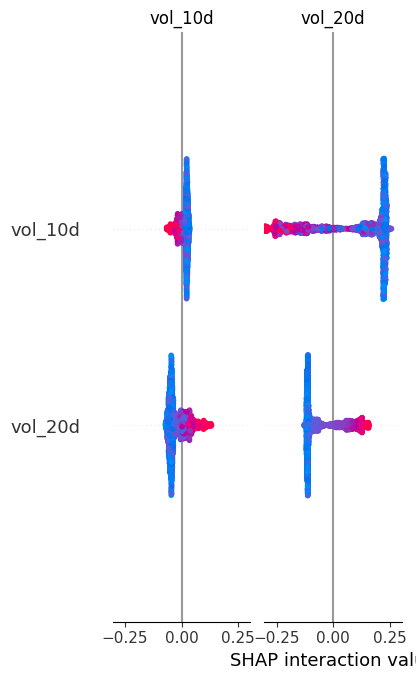

In [127]:
shap.summary_plot(
    shap_values.values,
    X_test_np,
    feature_names=FEATURES,
    plot_type="bar",
    show=True
)


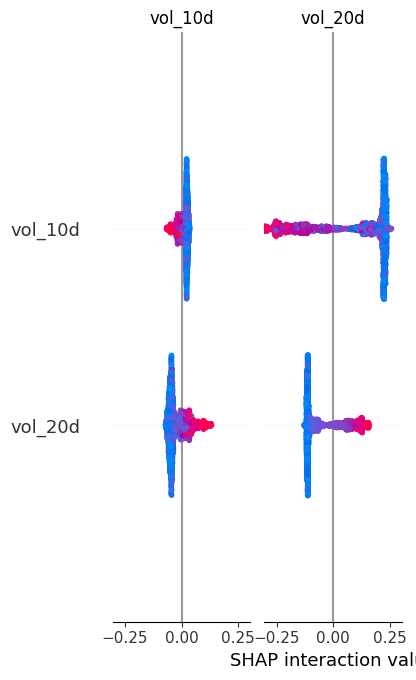

In [128]:
shap.summary_plot(
    shap_values.values,
    X_test_np,
    feature_names=FEATURES,
    show=True
)


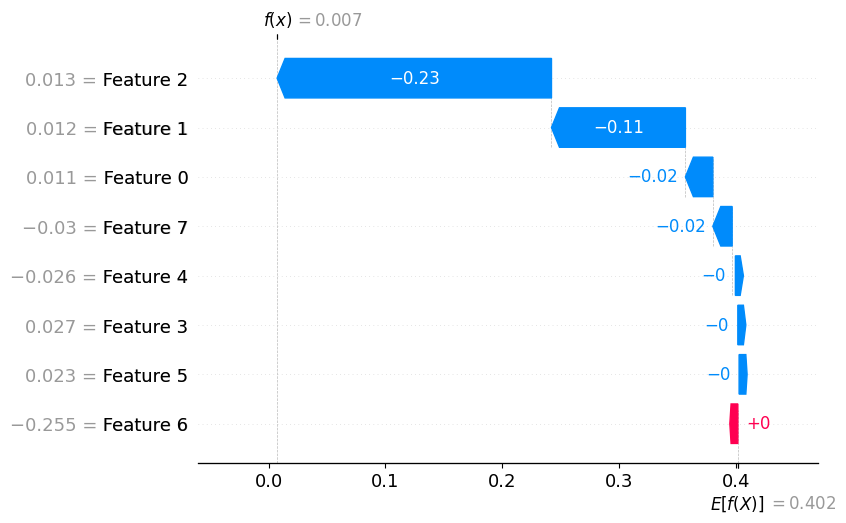

In [130]:
# pick any test index
idx = 25

# waterfall plot for POSITIVE CLASS (risk = 1)
shap.plots.waterfall(shap_values[idx, :, 1])


 99%|===================| 5123/5180 [01:28<00:00]       

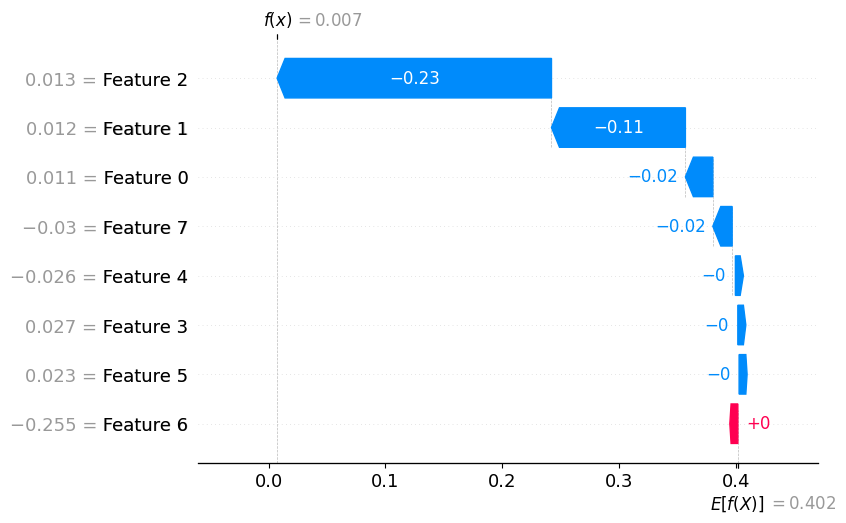

In [133]:
import shap
import numpy as np
feature_map = dict(enumerate(FEATURES))

# background dataset
X_bg = X_train.sample(200, random_state=42).values
X_test_np = X_test.values

# explainer
explainer = shap.Explainer(rf, X_bg)

# compute shap values
shap_values = explainer(X_test_np)

# single-sample explanation (risk class = 1)
idx = 25
shap.plots.waterfall(shap_values[idx, :, 1])


In [132]:
print(shap_values[idx].values.shape)       # (8, 2)
print(shap_values[idx, :, 1].values.shape) # (8,)


(8, 2)
(8,)


In [134]:
import matplotlib.pyplot as plt
import pandas as pd
import shap
import os

os.makedirs("figures", exist_ok=True)


In [135]:
def plot_price_risk(df, ticker, filename):
    data = df[df["ticker"] == ticker]

    plt.figure(figsize=(14,5))
    plt.plot(data["date"], data["close"], label="Price", linewidth=2)

    plt.scatter(
        data[data["risk_label"] == 1]["date"],
        data[data["risk_label"] == 1]["close"],
        color="red",
        s=15,
        label="High Risk"
    )

    plt.title(f"{ticker} Price with Predicted Risk Periods")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"figures/{filename}", dpi=150)
    plt.close()


In [137]:
prices_df = bq.query(f"""
SELECT date, ticker, close
FROM `{PROJECT_ID}.{DATASET_ID}.prices_clean`
""").to_dataframe(bqstorage_client=False)


In [138]:
risk_df = bq.query(f"""
SELECT date, ticker, risk_label
FROM `{PROJECT_ID}.{DATASET_ID}.model_dataset`
""").to_dataframe(bqstorage_client=False)


In [139]:
plot_df = prices_df.merge(
    risk_df,
    on=["date", "ticker"],
    how="inner"
)

plot_df.head()


,date,ticker,close,risk_label
0,1553731200000000000,AAPL,47.180000,0
1,1553817600000000000,AAPL,47.487499,0
2,1554076800000000000,AAPL,47.810001,0
3,1554163200000000000,AAPL,48.505001,0
4,1554249600000000000,AAPL,48.837502,0


In [142]:
import pandas as pd
import matplotlib.pyplot as plt
import shap
import os

os.makedirs("figures", exist_ok=True)

# Load price data
prices_df = bq.query(f"""
SELECT date, ticker, close
FROM `{PROJECT_ID}.{DATASET_ID}.prices_clean`
""").to_dataframe(bqstorage_client=False)

# Load risk labels
risk_df = bq.query(f"""
SELECT date, ticker, risk_label
FROM `{PROJECT_ID}.{DATASET_ID}.model_dataset`
""").to_dataframe(bqstorage_client=False)

# Merge for plotting
plot_df = prices_df.merge(
    risk_df,
    on=["date", "ticker"],
    how="inner"
)

plot_df["date"] = pd.to_datetime(plot_df["date"])


In [143]:
def plot_price_risk(df, ticker, filename):
    data = df[df["ticker"] == ticker]

    plt.figure(figsize=(14,5))
    plt.plot(data["date"], data["close"], label="Price", linewidth=2)

    plt.scatter(
        data[data["risk_label"] == 1]["date"],
        data[data["risk_label"] == 1]["close"],
        color="red",
        s=15,
        label="High Risk"
    )

    plt.title(f"{ticker} Price with Predicted Risk Periods")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"figures/{filename}", dpi=150)
    plt.close()

# Generate price plots
plot_price_risk(plot_df, "NVDA", "nvda_price_risk.png")
plot_price_risk(plot_df, "AAPL", "aapl_price_risk.png")
plot_price_risk(plot_df, "AMZN", "amzn_price_risk.png")


In [144]:
# Convert X_test to numpy if needed
X_test_np = X_test.values

# Pick one high-risk NVDA sample
nvda_idx = plot_df[
    (plot_df["ticker"] == "NVDA") & (plot_df["risk_label"] == 1)
].index[-1]

# Pick one low-risk AAPL sample
aapl_idx = plot_df[
    (plot_df["ticker"] == "AAPL") & (plot_df["risk_label"] == 0)
].index[-1]


In [146]:
# Recreate test_df with same filtering used earlier
df["date"] = pd.to_datetime(df["date"])

test_df = df[df["date"] >= "2024-01-01"].reset_index(drop=True)

# Sanity check
len(test_df), X_test.shape


(2590, (2590, 8))

In [147]:
nvda_idx = test_df[
    (test_df["ticker"] == "NVDA") &
    (test_df["risk_label"] == 1)
].index[-1]

nvda_idx


np.int64(2415)

In [148]:
aapl_idx = test_df[
    (test_df["ticker"] == "AAPL") &
    (test_df["risk_label"] == 0)
].index[-1]

aapl_idx


np.int64(517)

In [149]:
def save_shap_waterfall(idx, filename):
    plt.figure()
    shap.plots.waterfall(shap_values[idx, :, 1], show=False)
    plt.tight_layout()
    plt.savefig(f"figures/{filename}", dpi=150, bbox_inches="tight")
    plt.close()

save_shap_waterfall(nvda_idx, "nvda_shap_waterfall.png")
save_shap_waterfall(aapl_idx, "aapl_shap_waterfall.png")


In [151]:
import os
os.listdir("figures")


['nvda_price_risk.png',
 'nvda_shap_waterfall.png',
 'aapl_price_risk.png',
 'amzn_price_risk.png',
 '.ipynb_checkpoints',
 'aapl_shap_waterfall.png']

In [154]:
import matplotlib.pyplot as plt
import shap
import os

os.makedirs("figures", exist_ok=True)

# Use SHAP values for class 1 (high risk)
shap_class1 = shap_values.values[:, :, 1]   # shape: (n_samples, n_features)

plt.figure(figsize=(8,6))
shap.dependence_plot(
    "vol_10d",              # primary feature
    shap_class1,            # ✅ correct SHAP matrix
    X_test_np,              # feature matrix
    interaction_index="vol_20d",
    feature_names=FEATURES,
    show=False
)

plt.title("SHAP Interaction: vol_10d × vol_20d (High-Risk Class)")
plt.tight_layout()
plt.savefig("figures/amzn_shap_interaction.png", dpi=150)
plt.close()


In [155]:
import numpy as np
import pandas as pd
import json
import os

os.makedirs("dashboard_data", exist_ok=True)

# 1) Price + risk timeline data
plot_df.to_csv("dashboard_data/plot_df.csv", index=False)

# 2) SHAP metadata-aligned test dataframe (must match X_test rows)
test_df.to_csv("dashboard_data/test_df.csv", index=False)

# 3) Feature matrix used for SHAP (X_test)
X_test_np = X_test.values
np.save("dashboard_data/X_test.npy", X_test_np)

# 4) SHAP values (store full tensor; we'll select class 1 in app)
np.save("dashboard_data/shap_values.npy", shap_values.values)

# 5) Feature names
with open("dashboard_data/features.json", "w") as f:
    json.dump(FEATURES, f)

print("✅ Saved dashboard_data/ with plot_df.csv, test_df.csv, X_test.npy, shap_values.npy, features.json")


✅ Saved dashboard_data/ with plot_df.csv, test_df.csv, X_test.npy, shap_values.npy, features.json
